Code pour faire fonctionner pyspark (ne pas exécuter si pas besoin)

In [6]:
import os, subprocess, shutil
os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["PATH"] = r"C:\hadoop\bin;" + os.environ.get("PATH", "")
os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"
print("winutils:", os.path.exists(r"C:\hadoop\bin\winutils.exe"))
print("hadoop.dll:", os.path.exists(r"C:\hadoop\bin\hadoop.dll"))

os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot" 
os.environ["PATH"] = os.path.join(os.environ["JAVA_HOME"], "bin") + ";" + os.environ.get("PATH", "")
print("JAVA_HOME:", os.environ["JAVA_HOME"])
print("java in PATH:", shutil.which("java"))
print(subprocess.run(["java","-version"], capture_output=True, text=True).stderr)

winutils: False
hadoop.dll: False
JAVA_HOME: C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot
java in PATH: /opt/homebrew/opt/openjdk@17/bin/java
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment Homebrew (build 17.0.18+0)
OpenJDK 64-Bit Server VM Homebrew (build 17.0.18+0, mixed mode, sharing)



In [1]:
import sys, os
print("Python:", sys.executable)
print("Version:", sys.version)
print("PYSPARK_PYTHON:", os.environ.get("PYSPARK_PYTHON", "non défini"))
print("PYSPARK_DRIVER_PYTHON:", os.environ.get("PYSPARK_DRIVER_PYTHON", "non défini"))

Python: /Users/maugeear/.venvs/nf26_312/bin/python
Version: 3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 21.0.0 (clang-2100.0.123.102)]
PYSPARK_PYTHON: non défini
PYSPARK_DRIVER_PYTHON: non défini


In [2]:
import sys
# Affiche le chemin de l'exécutable Python utilisé par ce notebook
print(sys.executable)

/Users/maugeear/.venvs/nf26_312/bin/python


Etienne :

In [3]:
import sys, os
from pyspark.sql import SparkSession

if 'spark' in locals():
    spark.stop()

python_path = sys.executable  # ✅ chemin automatique
os.environ['PYSPARK_PYTHON'] = python_path
os.environ['PYSPARK_DRIVER_PYTHON'] = python_path

spark = (
    SparkSession.builder
    .appName("GHG-Inventory-ETL")
    .config("spark.driver.memory", "8g")
    .config("spark.python.worker.exec", python_path)
    .config("spark.sql.ansi.enabled", "false")
    .getOrCreate()
)

print("Python utilisé :", python_path)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/06 15:04:50 WARN Utils: Your hostname, MacBook-Pro-de-MAUGEE.local, resolves to a loopback address: 127.0.0.1; using 172.26.148.192 instead (on interface en0)
26/05/06 15:04:50 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/06 15:04:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Python utilisé : /Users/maugeear/.venvs/nf26_312/bin/python


In [220]:
import pandas as pd
import numpy as np
from pathlib import Path
import pyspark.pandas as ps
from pyspark.sql.functions import *
from datetime import date, timedelta
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import pandas as pd

# Sert à calculer les distances entre les villes
geolocator = Nominatim(user_agent="BGES_app")

## Partie ETL

#### Fonctions d'homogénéisation de la langue des fonctions et missions

In [221]:
def clean_langue_fonction(df, site):
    match site:
        case "BERLIN":
            map_fonctions = {
                "Ökonom": "Economist",
                "Führungskraft": "Business Executive",
                "Personalleiter": "HRD",
                "Computeringenieur": "Computer Engineer",
                "Dateningenieur": "Data Engineer",
            }
            df["FONCTION_PERSONNEL"] = df["FONCTION_PERSONNEL"].replace(map_fonctions)
        case "PARIS":
            map_fonctions = {
                "Ingénieur Informaticien": "Computer Engineer",
                "Ingénieur Data": "Data Engineer",
                "Economiste": "Economist",
                "DRH": "HRD",
                "Cadre": "Business Executive",
            }
            df["FONCTION_PERSONNEL"] = df["FONCTION_PERSONNEL"].replace(map_fonctions)


In [222]:
def clean_langue_mission(df, site):
    match site:
        case "BERLIN":
            map_type_mission = {
                "Geschäftstreffen": "Business Meeting",
                "Konferenz": "Conference",
                "Schulung": "Vocational Training",
                "Meeting": "Team Meeting",
                "Entwicklung": "Development",
            }
            df["TYPE_MISSION"] = df["TYPE_MISSION"].replace(map_type_mission)
        case "PARIS":
            map_type_mission = {
                "Conférence": "Conference",
                "Formation": "Vocational Training",
                "Réunion": "Team Meeting",
                "Rencontre entreprises": "Business Meeting",
                "Développement": "Development",
            }
            df["TYPE_MISSION"] = df["TYPE_MISSION"].replace(map_type_mission)


sites = ["PARIS", "LONDON", "BERLIN", "LOSANGELES", "NEWYORK", "SHANGHAI"]

#### Fonction d'homogénéisation des fuseaux horaires

In [223]:
def clean_date(df, site, date_col):
    """
    Convertit la colonne de dates d'un site donné vers UTC+2 (heure de Paris).
    Les dates sont supposées être en heure locale du site.
    """
    # Mapping site -> fuseau horaire IANA
    site_tz = {
        "PARIS":      "Europe/Paris",
        "BERLIN":     "Europe/Berlin",
        "LONDON":     "Europe/London",
        "NEWYORK":    "America/New_York",
        "LOSANGELES": "America/Los_Angeles",
        "SHANGHAI":   "Asia/Shanghai",
    }

    tz = site_tz[site]

    # S'assurer que la colonne est bien en datetime
    df[date_col] = pd.to_datetime(df[date_col])

    # Localiser la date dans le fuseau du site, puis convertir vers Paris (UTC+2 en été)
    df[date_col] = (
        df[date_col]
          .dt.tz_localize(tz, ambiguous=False, nonexistent='shift_forward') # on dit "cette heure est en heure locale du site"
          # le param ambiguous est utilisé pour les heures du changement d'heure
          .dt.tz_convert("Europe/Paris")  # on la convertit vers Paris
          .dt.tz_localize(None)           # on retire l'info de fuseau pour rester naive
    )

#### Chargement de l'ensemble des données du personnel

In [224]:
def extract_personnel():
    sites = ["PARIS", "BERLIN", "LONDON", "NEWYORK", "SHANGHAI", "LOSANGELES"]
    base_path = Path("data/BDD_BGES")

    personnel_dfs = []

    # On charge la liste du personnel de chaque site dans un dataframe
    for site in sites:
        file_path = base_path / f"BDD_BGES_{site}" / f"PERSONNEL_{site}.txt"
        df = pd.read_csv(str(file_path), sep=';')
        clean_langue_fonction(df, site) 
        df['ID_SITE'] = site
        
        personnel_dfs.append(df)

    # On combine les dataframes 
    personnel_df = pd.concat(personnel_dfs)
  
    # On sélectionne uniquement les colonnes nécessaires
    personnel_final_df = personnel_df[['ID_PERSONNEL','FONCTION_PERSONNEL', 'ID_SITE', 'DT_NAISS']]
    return personnel_final_df

def calcul_age(date_naissance, date_reference=None):
    if date_reference is None:
        date_reference = date.today()
    age = date_reference.year - date_naissance.year
    # Retire 1 an si l'anniversaire n'est pas encore passé
    if (date_reference.month, date_reference.day) < (date_naissance.month, date_naissance.day):
        age -= 1
    return age

def convertir_age_personnel(df_personnel, date_reference=None, timezone="UTC"):

    if date_reference is None:
        date_reference = date.today()
    
    df = df_personnel.copy()
    
    # Conversion au fuseau horaire général
    df["DT_NAISS"] = pd.to_datetime(df["DT_NAISS"], utc=True).dt.tz_convert(timezone)
    
    
    df["AGE"] = df["DT_NAISS"].apply(calcul_age)
    
    # Suppression de DT_NAISS
    df = df.drop(columns=["DT_NAISS"])
    
    return df

In [225]:
personnel_df = extract_personnel()
personnel_df = convertir_age_personnel(personnel_df, date_reference=date(2026, 9, 30))
personnel_df.head()

,ID_PERSONNEL,FONCTION_PERSONNEL,ID_SITE,AGE
0,KeyPers_Paris_1230000,Business Executive,PARIS,94
1,KeyPers_Paris_1230001,HRD,PARIS,63
2,KeyPers_Paris_1230002,Data Engineer,PARIS,47
3,KeyPers_Paris_1230003,Computer Engineer,PARIS,81
4,KeyPers_Paris_1230004,Computer Engineer,PARIS,45


In [226]:
age_max = personnel_df["AGE"].max()
age_min = personnel_df["AGE"].min()

print(age_max)
print(age_min)

96
24


PAS D'AGE ABERRANT A PRIORI

#### Traitement journalier des données de matériel informatique

In [227]:
def extract_materiel(start_date, end_date):
    sites = ["PARIS", "BERLIN", "LONDON", "NEWYORK", "SHANGHAI", "LOSANGELES"]
    base_path = Path("data/BDD_BGES")
    # Liste pour stocker les dataframes de chaque jour
    all_materiel_dfs = []

    # Boucle sur chaque jour
    for single_date in pd.date_range(start_date, end_date):
        day_str = single_date.strftime("%Y%m%d")
        
        # Liste pour stocker les dataframes de matériel de la journée
        materiel_day_dfs = []
        
        # Boucle sur chaque site
        for site in sites:
            file_path = base_path / f"BDD_BGES_{site}/BDD_BGES_{site}_INFORMATIQUE/MATERIEL_INFORMATIQUE_{day_str}.txt"
            
            # Vérifier si le fichier existe avant de le lire
            if file_path.exists():
                df = pd.read_csv(str(file_path), sep=';')
                clean_date(df, site, "DATE_ACHAT")
                df['ID_DATE'] = df['DATE_ACHAT'].dt.date #pour jointure 
                materiel_day_dfs.append(df)
                
        # Si des fichiers ont été trouvés pour ce jour
        if materiel_day_dfs:
            # Combiner les données de tous les sites pour la journée et l'ajouter à la liste globale
            all_materiel_dfs.append(pd.concat(materiel_day_dfs, ignore_index=True))

    # Après la boucle, vérifier si on a collecté des données
    if all_materiel_dfs:
        # Combiner les données de tous les jours en un seul DataFrame
        materiel_total_df = pd.concat(all_materiel_dfs, ignore_index=True)
        return materiel_total_df
    else:
        print("Aucun fichier de matériel trouvé pour la période spécifiée.")

In [228]:
start_date = date(2026, 4, 29)
end_date = date(2026, 11, 14) 

mat_df = extract_materiel(start_date, end_date)
mat_df.head()

,ID_MATERIELINFO,ID_PERSONNEL,NOM_PERSONNEL,PRENOM_PERSONNEL,DATE_ACHAT,TYPE,MODELE,ID_DATE
0,Paris_MATERIEL_INFO_202604290,KeyPers_Paris_1232362,Name2362,FistName2362,2026-04-29 08:17:31,PC fixe sans ecran,Z,2026-04-29
1,Paris_MATERIEL_INFO_202604291,KeyPers_Paris_1232165,Name2165,FistName2165,2026-04-29 09:42:55,imprimante,Laser A3 (>100kg),2026-04-29
2,Paris_MATERIEL_INFO_202604292,KeyPers_Paris_1231951,Name1951,FistName1951,2026-04-29 13:58:12,PC fixe sans ecran,Precision tower 3xxx,2026-04-29
3,Paris_MATERIEL_INFO_202604293,KeyPers_Paris_1230614,Name614,FistName614,2026-04-29 13:19:31,Telephone IP,,2026-04-29
4,Paris_MATERIEL_INFO_202604294,KeyPers_Paris_1232952,Name2952,FistName2952,2026-04-29 13:55:41,,modèle par défaut,2026-04-29


#### Traitement journalier des données de missions

In [229]:
# Même logique que la fonction d'extraction du matériel
def extract_missions(start_date, end_date):
    sites = ["PARIS", "BERLIN", "LONDON", "NEWYORK", "SHANGHAI", "LOSANGELES"]
    base_path = Path("data/BDD_BGES")
    
    all_missions_dfs = []

    for single_date in pd.date_range(start_date, end_date):
        day_str = single_date.strftime("%Y%m%d")
        
        missions_day_dfs = []
        
        for site in sites:
            file_path = base_path / f"BDD_BGES_{site}/BDD_BGES_{site}_MISSION/MISSION_{day_str}.txt"
            
            if file_path.exists():
                df = pd.read_csv(str(file_path), sep=';')
                clean_langue_mission(df, site)
                clean_date(df, site, "DATE_MISSION")
                df['ID_SITE'] = site
                df['ID_DATE'] = df['DATE_MISSION'].dt.date # pour jointure 
                missions_day_dfs.append(df)
                
        if missions_day_dfs:
            all_missions_dfs.append(pd.concat(missions_day_dfs, ignore_index=True))

    if all_missions_dfs :
        missions_total_df = pd.concat(all_missions_dfs, ignore_index=True)
        return missions_total_df
    else:
        print("Aucun fichier de missions trouvé pour la période spécifiée.")

In [230]:
missions_df = extract_missions(start_date, end_date)
missions_df.head()

/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_17745/3652553356.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col] = pd.to_datetime(df[date_col])
/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_17745/3652553356.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col] = pd.to_datetime(df[date_col])
/var/folders/ss/w7cbwmz1655gcl76m52qbcsh0000gn/T/ipykernel_17745/3652553356.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col] = pd.to_datetime(df[date_col])


,ID_MISSION,ID_PERSONNEL,NOM_PERSONNEL,PRENOM_PERSONNEL,DATE_MISSION,TYPE_MISSION,VILLE_DEPART,PAYS_DEPART,VILLE_DESTINATION,PAYS_DESTINATION,TRANSPORT,ALLER_RETOUR,ID_SITE,ID_DATE
0,Paris_202604290,KeyPers_Paris_1233578,Name3578,FistName3578,2026-04-29 15:01:12,Business Meeting,Paris,France,New-York,USA,Avion,oui,PARIS,2026-04-29
1,Paris_202604291,KeyPers_Paris_1234968,Name4968,FistName4968,2026-04-29 18:41:44,Development,Paris,France,London,England,Avion,oui,PARIS,2026-04-29
2,Paris_202604292,KeyPers_Paris_1233110,Name3110,FistName3110,2026-04-29 09:13:25,Business Meeting,Paris,France,Washington,USA,Avion,oui,PARIS,2026-04-29
3,Paris_202604293,KeyPers_Paris_1230093,Name93,FistName93,2026-04-29 13:04:44,Conference,Paris,France,Berlin,Allemagne,Avion,oui,PARIS,2026-04-29
4,Paris_202604294,KeyPers_Paris_1234582,Name4582,FistName4582,2026-04-29 15:34:56,Development,Paris,France,Montreal,Canada,Avion,oui,PARIS,2026-04-29


Passage des données nettoyées au format Pyspark SQL Dataframe pour préparer leur chargement dans les tables finales (Load). 

In [231]:
sdf_materiel = spark.createDataFrame(mat_df)
sdf_personnel = spark.createDataFrame(personnel_df)
sdf_mission = spark.createDataFrame(missions_df)

#### Création tables de dimension

In [232]:
dim_materiel = (
    sdf_materiel
    .select("ID_MATERIELINFO", "TYPE", "MODELE")
    .withColumnRenamed("ID_MATERIELINFO", "ID_MATERIEL")
)

In [233]:
try:
    dim_materiel.show(5)
except Exception as e:
    # Affiche le message complet avec toutes les causes
    full_msg = str(e)
    # Cherche "Caused by" qui contient la vraie erreur
    for line in full_msg.split('\n'):
        if 'Caused by' in line or 'IOException' in line or 'Error' in line or 'python' in line.lower():
            print(line)

+--------------------+------------------+--------------------+
|         ID_MATERIEL|              TYPE|              MODELE|
+--------------------+------------------+--------------------+
|Paris_MATERIEL_IN...|PC fixe sans ecran|                   Z|
|Paris_MATERIEL_IN...|        imprimante|   Laser A3 (>100kg)|
|Paris_MATERIEL_IN...|PC fixe sans ecran|Precision tower 3xxx|
|Paris_MATERIEL_IN...|      Telephone IP|                    |
|Paris_MATERIEL_IN...|                  |   modèle par défaut|
+--------------------+------------------+--------------------+
only showing top 5 rows


In [234]:
data = [("BERLIN",), ("LONDON",), ("LOSANGELES",), ("NEWYORK",), ("PARIS",), ("SHANGHAI",)]
dim_site = spark.createDataFrame(data).toDF("ID_SITE")

Traceback (most recent call last):
  File "/Users/maugeear/.venvs/nf26_312/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/maugeear/.venvs/nf26_312/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


In [235]:
dim_site.show(6)

+----------+
|   ID_SITE|
+----------+
|    BERLIN|
|    LONDON|
|LOSANGELES|
|   NEWYORK|
|     PARIS|
|  SHANGHAI|
+----------+



In [236]:
# Convertir toutes les dates au même format (date)
dates_missions = set(pd.to_datetime(missions_df['ID_DATE']))
dates_materiel = set(pd.to_datetime(mat_df['ID_DATE']))

# Combiner et trier
all_dates = sorted(dates_missions | dates_materiel)

# Créer la table de dimension
dim_date_data = [(d.date(),) for d in all_dates]
dim_date = spark.createDataFrame(dim_date_data, "ID_DATE date")

In [237]:
dim_date.show(5)

+----------+
|   ID_DATE|
+----------+
|2026-04-28|
|2026-04-29|
|2026-04-30|
|2026-05-01|
|2026-05-02|
+----------+
only showing top 5 rows


In [238]:
dim_personnel = sdf_personnel

In [239]:
dim_personnel.show(5)

+--------------------+------------------+-------+---+
|        ID_PERSONNEL|FONCTION_PERSONNEL|ID_SITE|AGE|
+--------------------+------------------+-------+---+
|KeyPers_Paris_123...|Business Executive|  PARIS| 94|
|KeyPers_Paris_123...|               HRD|  PARIS| 63|
|KeyPers_Paris_123...|     Data Engineer|  PARIS| 47|
|KeyPers_Paris_123...| Computer Engineer|  PARIS| 81|
|KeyPers_Paris_123...| Computer Engineer|  PARIS| 45|
+--------------------+------------------+-------+---+
only showing top 5 rows


Traceback (most recent call last):
  File "/Users/maugeear/.venvs/nf26_312/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/maugeear/.venvs/nf26_312/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


In [240]:
dim_mission = (
    sdf_mission
    .select(
        "ID_MISSION",
        "TYPE_MISSION",
        "VILLE_DEPART",
        "PAYS_DEPART",
        "VILLE_DESTINATION",
        "PAYS_DESTINATION",
        "TRANSPORT",
        "ALLER_RETOUR"
    )
)

In [241]:
dim_mission.show(5)

+---------------+----------------+------------+-----------+-----------------+----------------+---------+------------+
|     ID_MISSION|    TYPE_MISSION|VILLE_DEPART|PAYS_DEPART|VILLE_DESTINATION|PAYS_DESTINATION|TRANSPORT|ALLER_RETOUR|
+---------------+----------------+------------+-----------+-----------------+----------------+---------+------------+
|Paris_202604290|Business Meeting|       Paris|     France|         New-York|             USA|    Avion|         oui|
|Paris_202604291|     Development|       Paris|     France|           London|         England|    Avion|         oui|
|Paris_202604292|Business Meeting|       Paris|     France|       Washington|             USA|    Avion|         oui|
|Paris_202604293|      Conference|       Paris|     France|           Berlin|       Allemagne|    Avion|         oui|
|Paris_202604294|     Development|       Paris|     France|         Montreal|          Canada|    Avion|         oui|
+---------------+----------------+------------+---------

Traceback (most recent call last):
  File "/Users/maugeear/.venvs/nf26_312/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/maugeear/.venvs/nf26_312/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


#### Création tables de faits

In [242]:
fait_materiel = (
    sdf_materiel
    .join(dim_date, "ID_DATE", "inner")
    .join(sdf_personnel, "ID_PERSONNEL", "inner")
    .join(dim_site, "ID_SITE", "inner")
    .select(col("ID_MATERIELINFO").alias("ID_MATERIEL"), "ID_PERSONNEL", "ID_SITE", col("ID_DATE").alias("ID_DATE_ACHAT"))
)

In [243]:
fait_materiel.show(5)

+--------------------+--------------------+-------+-------------+
|         ID_MATERIEL|        ID_PERSONNEL|ID_SITE|ID_DATE_ACHAT|
+--------------------+--------------------+-------+-------------+
|BERLIN_MATERIEL_I...|KeyPers_Berlin_12...| BERLIN|   2026-05-10|
|BERLIN_MATERIEL_I...|KeyPers_Berlin_12...| BERLIN|   2026-05-10|
|BERLIN_MATERIEL_I...|KeyPers_Berlin_12...| BERLIN|   2026-05-10|
|BERLIN_MATERIEL_I...|KeyPers_Berlin_12...| BERLIN|   2026-05-10|
|BERLIN_MATERIEL_I...|KeyPers_Berlin_12...| BERLIN|   2026-04-30|
+--------------------+--------------------+-------+-------------+
only showing top 5 rows


In [244]:
fait_mission = (
    sdf_mission
    .join(dim_date, "ID_DATE", "inner")
    .join(sdf_personnel, "ID_PERSONNEL", "inner")
    .join(dim_site, "ID_SITE", "inner")
    .select("ID_MISSION", "ID_PERSONNEL", sdf_mission.ID_SITE, col("ID_DATE").alias("ID_DATE_MISSION"))
)

In [245]:
fait_mission.show(5)

+----------------+--------------------+-------+---------------+
|      ID_MISSION|        ID_PERSONNEL|ID_SITE|ID_DATE_MISSION|
+----------------+--------------------+-------+---------------+
|BERLIN_202605100|KeyPers_Berlin_12...| BERLIN|     2026-05-10|
|BERLIN_202605101|KeyPers_Berlin_12...| BERLIN|     2026-05-10|
|BERLIN_202605102|KeyPers_Berlin_12...| BERLIN|     2026-05-10|
|BERLIN_202605103|KeyPers_Berlin_12...| BERLIN|     2026-05-10|
|BERLIN_202605104|KeyPers_Berlin_12...| BERLIN|     2026-05-10|
+----------------+--------------------+-------+---------------+
only showing top 5 rows


## Réponse aux questions

1. Combien de cadres travaillent sur le site de Paris ?

In [246]:
nb_cadres_paris = (
    dim_personnel
    .filter(col("ID_SITE") == "PARIS")
    .filter(col("FONCTION_PERSONNEL") == "Business Executive")
    .count()
)

print(f"{nb_cadres_paris} cadres travaillent sur le site de Paris")

929 cadres travaillent sur le site de Paris


2. Combien d’ingénieurs Data travaillent sur les sites aux États-Unis ?

In [247]:
nb_inge_data_us = (
    dim_personnel
    .filter((col("ID_SITE") == "LOSANGELES") |  (col("ID_SITE") == "NEWYORK"))
    .filter(col("FONCTION_PERSONNEL") == "Data Engineer")
    .count()
)

print(f"{nb_inge_data_us} ingénieurs Data travaillent sur les sites aux États-Unis")

2197 ingénieurs Data travaillent sur les sites aux États-Unis


3. Combien d’ingénieurs informaticiens travaillent dans l’organisation (tous sites compris) ?

In [248]:
nb_inge_info = (
    dim_personnel
    .filter(col("FONCTION_PERSONNEL") == "Computer Engineer")
    .count()
)

print(f"{nb_inge_info} ingénieurs informaticiens travaillent dans l'organisation (tous sites compris)")

7696 ingénieurs informaticiens travaillent dans l'organisation (tous sites compris)


4. Combien de PC fixes ont été achetés par l’organisation entre juin et septembre 2026 ?

In [249]:
nb_pc_fixes = (
    dim_materiel
    .filter((col("TYPE") == "PC fixe sans ecran") | (col("TYPE") == "PC fixe tout-en-un"))
    .join(fait_materiel, "ID_MATERIEL")
    .filter((col("ID_DATE_ACHAT") >= date(2026, 6, 1)) & (col("ID_DATE_ACHAT") <= date(2026, 9, 30)))
    .count()
)

print(f"{nb_pc_fixes} PC fixes ont été achetés entre juin et septembre 2026")

1585 PC fixes ont été achetés entre juin et septembre 2026


5. Quelle a été l’impact carbone des PC fixes sans ecran entre mai et octobre 2026 ?

In [250]:
# On charge le fichier qui contient l'impact carbone du matériel informatique. 
import unicodedata

impact_mat_info_psdf = ps.read_csv("./data/BDD_BGES/materiel_informatique_impact.csv")
impact_mat_info_sdf = impact_mat_info_psdf.to_spark()

#Fonction pour retirer les accents et convertir en majuscules
def remove_accents_and_uppercase(name):
    #Normaliser et retirer les accents
    normalized = unicodedata.normalize('NFD', name)
    without_accents = ''.join(char for char in normalized if unicodedata.category(char) != 'Mn')
    return without_accents.upper()

# Convertir tous les noms de colonnes en majuscules sans accents pour pouvoir faire les jointures
impact_mat_info_sdf = impact_mat_info_sdf.select([col(c).alias(remove_accents_and_uppercase(c)) for c in impact_mat_info_sdf.columns])

impact_mat_info_sdf.show(5)

+------------------+-----------------+------+
|              TYPE|           MODELE|IMPACT|
+------------------+-----------------+------+
|PC fixe sans ecran|modèle par défaut|   350|
|PC fixe sans ecran|   Optiplex micro|   174|
|PC fixe sans ecran|   Optiplex small|   240|
|PC fixe sans ecran|   Optiplex tower|   260|
|PC fixe sans ecran| Wyse thin client|    69|
+------------------+-----------------+------+
only showing top 5 rows


/Users/maugeear/.venvs/nf26_312/lib/python3.12/site-packages/pyspark/pandas/utils.py:1038: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `read_csv`, the default index is attached which can cause additional overhead.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)
/Users/maugeear/.venvs/nf26_312/lib/python3.12/site-packages/pyspark/pandas/utils.py:1038: PandasAPIOnSparkAdviceWarning: If `index_col` is not specified for `to_spark`, the existing index is lost when converting to Spark DataFrame.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


In [251]:
impact_pc_fixes = (
    dim_materiel
    .filter(col("TYPE") == "PC fixe sans ecran")
    .join(fait_materiel, "ID_MATERIEL")
    .filter((col("ID_DATE_ACHAT") >= date(2026, 5, 1)) & (col("ID_DATE_ACHAT") <= date(2026, 10, 31)))
    .join(impact_mat_info_sdf, ["TYPE", "MODELE"])
    .agg(sum(col("IMPACT")))
    .first()[0]
)

#On divise par 1000 car les unités dans le tableau du matériel sont en kgCO2e
print(f"L'impact des PC fixes sans ecran a été de {impact_pc_fixes/1000} tCO2e entre mai et octobre 2026")

L'impact des PC fixes sans ecran a été de 480.921 tCO2e entre mai et octobre 2026


6. Quelle a été l’impact carbone des PC portables achetés par les ingénieurs Data entre mai et octobre 2026 sur les sites de Londres et New-York ?

In [252]:
impact_pc_portables = (
    dim_personnel
    .filter((col("ID_SITE") == "LONDON") |  (col("ID_SITE") == "NEWYORK"))
    .filter(col("FONCTION_PERSONNEL") == "Data Engineer")
    .join(fait_materiel, "ID_PERSONNEL")
    .filter((col("ID_DATE_ACHAT") >= date(2026, 5, 1)) & (col("ID_DATE_ACHAT") <= date(2026, 10, 31)))
    .join(dim_materiel, "ID_MATERIEL")
    .filter(col("TYPE") == "PC portable")
    .join(impact_mat_info_sdf, ["TYPE", "MODELE"])
    .agg(sum(col("IMPACT")))
    .first()[0]
)

print(f"L'impact des PC portables achetés entre mai et octobre 2026 par les ingénieurs Data sur les sites de Londres et New-York a été de {impact_pc_portables/1000} tCO2e")

L'impact des PC portables achetés entre mai et octobre 2026 par les ingénieurs Data sur les sites de Londres et New-York a été de 61.723 tCO2e


7. Quelle a été l’impact carbone des Ecrans achetés par les cadres entre juillet et septembre 2026 sur tous les sites de l’organisation ?

In [253]:
impact_ecrans = (
    dim_personnel
    .filter(col("FONCTION_PERSONNEL") == "Business Executive")
    .join(fait_materiel, "ID_PERSONNEL")
    .filter((col("ID_DATE_ACHAT") >= date(2026, 7, 1)) & (col("ID_DATE_ACHAT") <= date(2026, 9, 30)))
    .join(dim_materiel, "ID_MATERIEL")
    .filter(col("TYPE") == "Ecran")
    .join(impact_mat_info_sdf, ["TYPE", "MODELE"])
    .agg(sum(col("IMPACT")))
    .first()[0]
)

print(f"L'impact des écrans achetés entre juillet et septembre 2026 par les cadres sur tous les sites a été de {impact_ecrans/1000} tCO2e")

L'impact des écrans achetés entre juillet et septembre 2026 par les cadres sur tous les sites a été de 11.8 tCO2e


8. Quelle a été l’impact carbone des missions sur les sites Européens entre mai et octobre 2026 ?

Clarification de "transports en communs" : 
Sur le site labos1.5, on a plusieurs types de transports en commun, dont deux qui ne sont pas pris en compte dans la liste donnée dans le sujet (bus et bateau). Cependant, quand on regarde dans la liste des missions, on constate que les missions labellisées transport en commun ont toutes la même ville d'arrivée et de départ, cf exécuter le code suivant : 

missions_df[(missions_df["TRANSPORT"] == "Transports en commun") & (missions_df["VILLE_DEPART"] != missions_df["VILLE_DESTINATION"])]

On considère donc que les trajets en transport peuvent être représentés par des trajets en bus. Sur le site de labo1.5 on trouve : 

Spécificité des déplacements en bus :
Nous faisons l’hypothèse que les trajets en bus inter-urbains seront majoritaires en terme de distances parcourues lors d’une mission, comparativement aux trajets en bus urbains. Les trajets inter-urbains étant moins émetteurs que les trajets urbains, nous prenons le facteur d’émission le moins élevé parmi les 3 facteurs disponibles dans la Base Carbone: c’est celui des bus dans des agglomérations de plus de 250 000 habitants.

Ce facteur sera donc utilisé pour les déplacements en transports en commun. 

Fonction permettant de calculer la distance entre 2 villes : 

In [254]:
#Dictionnaire des coefficients en fonction du mode de transport
COEFFS_DISTANCE = {
    "Train" : 1.2,
    "Taxi" : 1.2,
    "Transports en commun" : 1.5
}

# Dictionnaire de coordonnées pour éviter les appels répétés et la limitation API GeoPy
CITY_COORDS = {
    # Sites principaux
    ("Paris", "France"): (48.8566, 2.3522),
    ("Berlin", "Germany"): (52.5200, 13.4050),
    ("Berlin", "Allemagne"): (52.5200, 13.4050),
    ("London", "England"): (51.5074, -0.1278),
    ("New York", "USA"): (40.7128, -74.0060),
    ("New-York", "USA"): (40.7128, -74.0060),
    ("Los Angeles", "USA"): (34.0522, -118.2437),
    ("Shanghai", "China"): (31.2304, 121.4737),
    ("Marseille", "France"): (43.2965, 5.3698),
    ("Compiègne", "France"): (49.4144, 2.8259),
    ("Stockholm", "Sweden"): (59.3293, 18.0686),
    ("Stockholm", "Suède"): (59.3293, 18.0686),
    ("Helsinki", "Finland"): (60.1695, 24.9354),
    ("Helsinki", "Finlande"): (60.1695, 24.9354),
    ("Osaka", "Japan"): (34.6937, 135.5023),
    ("Tokyo", "Japan"): (35.6762, 139.6503),
    ("Melbourne", "Australia"): (-37.8136, 144.9631),
    ("Sydney", "Australia"): (-33.8688, 151.2093),
    ("Sidney", "Australia"): (-33.8688, 151.2093),
    ("Wellington", "New Zealand"): (-41.2865, 174.7762),
    ("Montreal", "Canada"): (45.5017, -73.5673),
    ("Vancouver", "Canada"): (49.2827, -123.1207),
    ("Washington", "USA"): (38.9072, -77.0369),
    ("Buenos Aires", "Argentina"): (-34.6037, -58.3816),
    ("Bogota", "Colombia"): (4.7110, -74.0721),
    ("Rio de Janeiro", "Brazil"): (-22.9068, -43.1729),
    ("Rabat", "Morocco"): (34.0209, -6.8416),
    ("Rabat", "Maroc"): (34.0209, -6.8416),
    ("Dubaï", "Emirats"): (25.2048, 55.2708),
    ("Mexico", "Mexico"): (19.4326, -99.1332),
    ("Tunis", "Tunisia"): (36.8065, 10.1686),
    ("Tunis", "Tunisie"): (36.8065, 10.1686),
    ("Sao Paulo", "Brazil"): (-23.5505, -46.6333),
    ("Stockholm", "Sweden"): (59.3293, 18.0686),
    ("Stockholm", "Suede"): (59.3293, 18.0686),
    ("Alger", "Algeria"): (36.7538, 3.0588),
    ("Auckland", "New Zealand"): (-37.0882, 174.8860),
    ("Bordeaux", "France"): (44.8378, -0.5792),
    ("Pekin", "China"): (39.9042, 116.4074),
    ("Beijing", "China"): (39.9042, 116.4074),
    ("Lille", "France"): (50.6292, 3.0573),
    ("Oslo", "Norvège"): (59.9139, 10.7522),
    ("Oslo", "Norway"): (59.9139, 10.7522),
    ("Lima", "Peru"): (-12.0464, -77.0428)
}

def get_distance_between_cities(ville_depart, pays_depart, ville_destination, pays_destination):
    try:
        # Chercher dans le dictionnaire d'abord
        coords_depart = CITY_COORDS.get((ville_depart, pays_depart))
        coords_dest = CITY_COORDS.get((ville_destination, pays_destination))
        
        # Si ville de départ non trouvée, appeler Nominatim
        if not coords_depart:
            print("ville depart non présente: ", ville_depart)
            print("pays depart non présent: ", pays_depart)
            location_depart = geolocator.geocode(f"{ville_depart}, {pays_depart}", timeout=10)
            if location_depart:
                coords_depart = (location_depart.latitude, location_depart.longitude)
        
        # Si ville de destination non trouvée, appeler Nominatim
        if not coords_dest:
            print("ville arrivee non présente: ", ville_destination)
            print("pays arrivee non présent: ", pays_destination)
            location_destination = geolocator.geocode(f"{ville_destination}, {pays_destination}", timeout=10)
            if location_destination:
                coords_dest = (location_destination.latitude, location_destination.longitude)
        
        # Si les deux coordonnées ont été trouvées, calculer la distance
        if coords_depart and coords_dest:
            distance_km = geodesic(coords_depart, coords_dest).kilometers
            return distance_km
        else:
            return None
            
    except Exception as e:
        print(f"Erreur lors du calcul: {e}")
        return None

Fonction permettant de calculer les emissions : 

In [255]:
def get_emission(distance, transport, ar, pays_depart, pays_destination):
        
        #Chargement des fichiers permettant de récupérer les facteurs d'émission
        base_path = Path("data/facteurs_emission")
        fe_transports_en_commun_df = pd.read_csv(base_path / "fe_transports_en_commun.tsv", sep='\t')
        fe_vehicules_df = pd.read_csv(base_path / "fe_vehicules.tsv", sep='\t')
        fe_transports_en_commun_df.head(100)


        #Multiplicateur si le trajet est un aller-retour
        multAr = 2 if ar == "oui" else 1

        #Modification de la distance en fonction du moyen de transport
        if(transport == "Avion"):
            distance += 95
        else : 
            distance *= COEFFS_DISTANCE.get(transport)
        
        #Calcul du facteur et de l'emission totale en fonction du moyen de transport
        #On divise par 1000 à chaque fois pour renvoyer la quantité directement en tCO2e
        match transport:
            case "Avion":
                if distance < 1000:
                    facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "Court courrier (< 1000 km)"]["total"].iloc[0]
                elif distance < 3500:
                    facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "Moyen courrier (< 1001 - 3500km)"]["total"].iloc[0]
                else:
                    facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "Long courrier (> 3500 km)"]["total"].iloc[0]
                
                return distance*facteur*multAr/1000

            
            case "Train":
                if(pays_depart == "France"):
                    if(pays_destination == "France"):
                        if distance > 200 :
                            facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "TGV > 200 km"]["total"].iloc[0]
                        else:
                            facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "Train < 200 km"]["total"].iloc[0]
                    else:
                        facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "Train mixte France et international"]["total"].iloc[0]
                else:
                    if(pays_destination == "France"):
                        facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "Train mixte France et international"]["total"].iloc[0]
                    else:
                        facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "Train international"]["total"].iloc[0]
                
                return distance*facteur*multAr/1000
            
            case "Taxi":
                facteur = fe_vehicules_df[fe_vehicules_df["subsubcategory"] == "Motorisation inconnue"]["total"].iloc[0]
                #On calcule aussi les émissions pour le trajet aller (on condisère 2 personnes à bord)
                #et retour (on considère le chauffeur seul à bord)
                em = (distance * (1 + 1/2) * facteur) + (distance * (1 + 1/1) * facteur)
                return multAr*em/1000
            
            case "Transports en commun":
                facteur = fe_transports_en_commun_df[fe_transports_en_commun_df["subsubcategory"] == "Bus > 250 000 habitants"]["total"].iloc[0]
                return distance*facteur*multAr/1000

Réponse à la question :

In [256]:
#On isole les missions concernées
missions = (
    dim_mission
    .join(fait_mission, "ID_MISSION")
    .filter((col("ID_SITE") == "PARIS") | (col("ID_SITE") == "LONDON") | (col("ID_SITE") == "BERLIN"))
    .filter((col("ID_DATE_MISSION") >= date(2026, 5, 1)) & (col("ID_DATE_MISSION") <= date(2026, 10, 31)))
    .select("VILLE_DEPART","PAYS_DEPART", "VILLE_DESTINATION","PAYS_DESTINATION","ALLER_RETOUR","TRANSPORT")
)

#On converti en Dataframe Pandas pour les calculs
missions_df = missions.toPandas()

In [257]:
#On applique la fonction de calcul des distances à chaque mission et on sauvegarde le résultat
#dans une nouvelle colonne.
missions_df['DISTANCE_KM'] = missions_df.apply(
    lambda row: get_distance_between_cities(
        row['VILLE_DEPART'],
        row['PAYS_DEPART'],
        row['VILLE_DESTINATION'],
        row['PAYS_DESTINATION'],
    ),
    axis=1
)

In [259]:
#On applique la fonction de calcul des emissions et on sauvegarde le résultat dans une nouvelle colonne
missions_df['EMISSION'] = missions_df.apply(
    lambda row: get_emission(
        row['DISTANCE_KM'],
        row['TRANSPORT'],
        row['ALLER_RETOUR'],
        row['PAYS_DEPART'],
        row['PAYS_DESTINATION']
    ),
    axis=1
)

In [ ]:
total_emission = missions_df['EMISSION'].sum()
print(f"L’impact carbone des missions sur les sites Européens entre mai et octobre 2026 est de {total_emission:.2f} tCO2e.")

L’impact carbone des missions sur les sites Européens entre mai et octobre 2026 est de 25729.06 tCO2e.


9. Quels ont été les 5 jours les plus impactents concernant les missions en avion pour les sites Européens de l’organisation ?

In [ ]:
missions_avion = (
    dim_mission
    .filter(col("TRANSPORT") == "Avion")
    .join(fait_mission, "ID_MISSION")
    .filter((col("ID_SITE") == "PARIS") | (col("ID_SITE") == "LONDON") | (col("ID_SITE") == "BERLIN"))
    .select("VILLE_DEPART","PAYS_DEPART", "VILLE_DESTINATION","PAYS_DESTINATION","ALLER_RETOUR","TRANSPORT","ID_DATE_MISSION")
)

missions_df = missions_avion.toPandas()

In [ ]:
#Calcul des émissions pour chaque mission
missions_df['DISTANCE_KM'] = missions_df.apply(
    lambda row: get_distance_between_cities(
        row['VILLE_DEPART'],
        row['PAYS_DEPART'],
        row['VILLE_DESTINATION'],
        row['PAYS_DESTINATION'],
    ),
    axis=1
)

missions_df['EMISSION'] = missions_df.apply(
    lambda row: get_emission(
        row['DISTANCE_KM'],
        row['TRANSPORT'],
        row['ALLER_RETOUR'],
        row['PAYS_DEPART'],
        row['PAYS_DESTINATION']
    ),
    axis=1
)

In [ ]:
# Grouper par date et faire la somme des émissions pour chaque date
emissions_par_jour = missions_df.groupby('ID_DATE_MISSION')['EMISSION'].sum().reset_index()
emissions_par_jour.columns = ['Date', 'Emission_tCO2e']

# Trier par émissions décroissantes et prendre les 5 premiers jours
top_5_jours = emissions_par_jour.nlargest(5, 'Emission_tCO2e').reset_index(drop=True)

# Resultat
print("Les 5 jours les plus impactants concernant les missions en avion pour les sites européens sont :\n")
print(top_5_jours.to_string(index=False))

Les 5 jours les plus impactants concernant les missions en avion pour les sites européens sont :

      Date  Emission_tCO2e
2026-08-05      235.700371
2026-05-15      217.388351
2026-05-30      217.320879
2026-07-22      215.176076
2026-10-04      210.852861


10. Quel a été le secteur d’activité qui a eu le plus d’impact concernant les missions et le matériel informatique sur l’ensemble des
sites de l’organisation ?

On considère que secteur d'activité = fonction personnel

Mission : 

In [ ]:
missions = (
    dim_mission
    .join(fait_mission, "ID_MISSION")
    .join(dim_personnel, "ID_PERSONNEL")
    .select("VILLE_DEPART", "PAYS_DEPART", "VILLE_DESTINATION","PAYS_DESTINATION","ALLER_RETOUR","TRANSPORT", "FONCTION_PERSONNEL")
)

missions_df = missions.toPandas()

#Calcul des émissions pour chaque mission
missions_df['DISTANCE_KM'] = missions_df.apply(
    lambda row: get_distance_between_cities(
        row['VILLE_DEPART'],
        row['PAYS_DEPART'],
        row['VILLE_DESTINATION'],
        row['PAYS_DESTINATION'],
    ),
    axis=1
)

missions_df['EMISSION'] = missions_df.apply(
    lambda row: get_emission(
        row['DISTANCE_KM'],
        row['TRANSPORT'],
        row['ALLER_RETOUR'],
        row['PAYS_DEPART'],
        row['PAYS_DESTINATION']
    ),
    axis=1
)

In [ ]:
emissions_par_secteur = missions_df.groupby('FONCTION_PERSONNEL')['EMISSION'].sum().sort_values(ascending=False).reset_index()
emissions_par_secteur.columns = ['FONCTION_PERSONNEL', 'Emission_tCO2e']
emissions_par_secteur

,FONCTION_PERSONNEL,Emission_tCO2e
0,Data Engineer,20907.021431
1,Computer Engineer,20597.152319
2,Business Executive,10164.880236
3,Economist,3298.084766
4,HRD,1012.128274


Materiel :

In [ ]:
mat_inf = (
    dim_materiel
    .join(fait_materiel, "ID_MATERIEL")
    .join(dim_personnel, "ID_PERSONNEL")
    .select("FONCTION_PERSONNEL", "ID_MATERIEL", "TYPE", "MODELE")
)

impact_mat = (
    mat_inf
    .join(impact_mat_info_sdf, ["TYPE", "MODELE"])
    .groupBy(col("FONCTION_PERSONNEL"))
    .agg(sum(col("IMPACT")))
)

impact_mat_df = impact_mat.toPandas()
impact_mat_df["sum(IMPACT)"] = impact_mat_df["sum(IMPACT)"] / 1000
impact_mat_df

,FONCTION_PERSONNEL,sum(IMPACT)
0,Computer Engineer,848.214
1,HRD,44.209
2,Business Executive,398.936
3,Economist,142.665
4,Data Engineer,802.961


Jointure materiel et mission pour avoir la somme des impacts

In [ ]:
#Homogénéisation du type de données
emissions_par_secteur["FONCTION_PERSONNEL"] = emissions_par_secteur["FONCTION_PERSONNEL"].astype(str)
impact_mat_df["FONCTION_PERSONNEL"] = impact_mat_df["FONCTION_PERSONNEL"].astype(str)

#Jointure et calcul du total (missions + matériel)
jointure = emissions_par_secteur.merge(impact_mat_df, on="FONCTION_PERSONNEL")
jointure["TOT_IMPACT"] = jointure["Emission_tCO2e"] + jointure["sum(IMPACT)"]
jointure.sort_values("TOT_IMPACT", ascending=False)

,FONCTION_PERSONNEL,Emission_tCO2e,sum(IMPACT),TOT_IMPACT
0,Data Engineer,20907.021431,802.961,21709.982431
1,Computer Engineer,20597.152319,848.214,21445.366319
2,Business Executive,10164.880236,398.936,10563.816236
3,Economist,3298.084766,142.665,3440.749766
4,HRD,1012.128274,44.209,1056.337274


11. Quel site a eu le plus d’impact concernant les missions et le matériel informatique sur l’ensemble des sites de l’organisation ?

MISSION : 

In [ ]:
missions = (
    dim_mission
    .join(fait_mission, "ID_MISSION")
    .select("ID_SITE","VILLE_DEPART","PAYS_DEPART", "VILLE_DESTINATION","PAYS_DESTINATION","ALLER_RETOUR","TRANSPORT","ID_DATE_MISSION")
)

missions_df = missions.toPandas()

#Calcul des émissions pour chaque mission
missions_df['DISTANCE_KM'] = missions_df.apply(
    lambda row: get_distance_between_cities(
        row['VILLE_DEPART'],
        row['PAYS_DEPART'],
        row['VILLE_DESTINATION'],
        row['PAYS_DESTINATION'],
    ),
    axis=1
)

missions_df['EMISSION'] = missions_df.apply(
    lambda row: get_emission(
        row['DISTANCE_KM'],
        row['TRANSPORT'],
        row['ALLER_RETOUR'],
        row['PAYS_DEPART'],
        row['PAYS_DESTINATION']
    ),
    axis=1
)

In [ ]:
emissions_par_site = missions_df.groupby('ID_SITE')['EMISSION'].sum().sort_values(ascending=False).reset_index()
emissions_par_site.columns = ['ID_SITE', 'Emission_tCO2e']
emissions_par_site

,ID_SITE,Emission_tCO2e
0,LOSANGELES,11777.110260
1,NEWYORK,9744.819767
2,BERLIN,9644.800454
3,LONDON,9400.541652
4,PARIS,8790.725411
5,SHANGHAI,6621.269482


MATERIEL : 

In [ ]:
mat_inf = (
    dim_materiel
    .join(fait_materiel, "ID_MATERIEL")
    .select("ID_SITE", "ID_MATERIEL", "TYPE", "MODELE")
)

impact_mat = (
    mat_inf
    .join(impact_mat_info_sdf, ["TYPE", "MODELE"])
    .groupBy(col("ID_SITE"))
    .agg(sum(col("IMPACT")))
)

impact_mat_df = impact_mat.toPandas()
impact_mat_df["sum(IMPACT)"] = impact_mat_df["sum(IMPACT)"] / 1000
impact_mat_df

,ID_SITE,sum(IMPACT)
0,BERLIN,193.391
1,LONDON,392.340
2,LOSANGELES,424.573
3,NEWYORK,421.602
4,PARIS,419.218
5,SHANGHAI,385.861


JOINTURE DE MATERIEL ET MISSION POUR FAIRE LA SOMME DES IMPACTS

In [ ]:
#Homogénéisation du type de données
emissions_par_site["ID_SITE"] = emissions_par_site["ID_SITE"].astype(str)
impact_mat_df["ID_SITE"] = impact_mat_df["ID_SITE"].astype(str)

#Jointure et calcul du total (missions + matériel)
jointure = emissions_par_site.merge(impact_mat_df, on="ID_SITE")
jointure["TOT_IMPACT"] = jointure["Emission_tCO2e"] + jointure["sum(IMPACT)"]
jointure.sort_values("TOT_IMPACT", ascending=False)

,ID_SITE,Emission_tCO2e,sum(IMPACT),TOT_IMPACT
0,LOSANGELES,11777.110260,424.573,12201.683260
1,NEWYORK,9744.819767,421.602,10166.421767
2,BERLIN,9644.800454,193.391,9838.191454
3,LONDON,9400.541652,392.340,9792.881652
4,PARIS,8790.725411,419.218,9209.943411
5,SHANGHAI,6621.269482,385.861,7007.130482


Question 12 : Quel a été l’impact carbone des missions reliant chaque site (la ville de départ est un site de l’organisation et la ville d’arrivée
également) durant le mois de septembre 2026 ?

In [ ]:
missions_avion = (
    dim_mission
    .join(fait_mission, "ID_MISSION")
    .filter(upper(col("VILLE_DEPART")).isin(sites) & upper(col("VILLE_DESTINATION")).isin(sites))
    .filter((col("ID_DATE_MISSION") >= date(2026, 9, 1)) & (col("ID_DATE_MISSION") <= date(2026, 9, 30)))
    .select("VILLE_DEPART", "PAYS_DEPART", "VILLE_DESTINATION", "PAYS_DESTINATION", "ALLER_RETOUR", "TRANSPORT", "ID_DATE_MISSION")
)

missions_df = missions_avion.toPandas()
missions_df

,VILLE_DEPART,PAYS_DEPART,VILLE_DESTINATION,PAYS_DESTINATION,ALLER_RETOUR,TRANSPORT,ID_DATE_MISSION
0,London,England,Shanghai,China,oui,Avion,2026-09-06
1,London,England,Berlin,Allemagne,oui,Avion,2026-09-24
2,Berlin,Allemagne,Berlin,Allemagne,oui,Transports en commun,2026-09-24
3,London,England,Shanghai,China,oui,Avion,2026-09-17
4,London,England,London,England,oui,Transports en commun,2026-09-07
...,...,...,...,...,...,...,...
242,London,England,London,England,oui,Transports en commun,2026-09-21
243,Paris,France,London,England,oui,Avion,2026-09-13
244,Paris,France,Berlin,Allemagne,oui,Avion,2026-09-26
245,Shanghai,China,Berlin,Allemagne,oui,Avion,2026-09-10


In [ ]:
#Calcul des émissions pour chaque mission
missions_df['DISTANCE_KM'] = missions_df.apply(
    lambda row: get_distance_between_cities(
        row['VILLE_DEPART'],
        row['PAYS_DEPART'],
        row['VILLE_DESTINATION'],
        row['PAYS_DESTINATION'],
    ),
    axis=1
)

missions_df['EMISSION'] = missions_df.apply(
    lambda row: get_emission(
        row['DISTANCE_KM'],
        row['TRANSPORT'],
        row['ALLER_RETOUR'],
        row['PAYS_DEPART'],
        row['PAYS_DESTINATION']
    ),
    axis=1
)

In [ ]:
print(f"L’impact carbone des missions reliant chaque site durant le mois de septembre 2026 est de {missions_df["EMISSION"].sum()} tCO2e")

L’impact carbone des missions reliant chaque site durant le mois de septembre 2026 est de 273.64634800501995 tCO2e


Question 13 : Quel a été l’impact carbone des séminaires en juillet 2026 pour les employés de Los Angeles ?

In [ ]:
seminaires_la = (
    dim_mission
    .filter((col("TYPE_MISSION")) == "Conference")  # adapter si le type exact est différent
    .join(fait_mission, "ID_MISSION")
    .filter((col("ID_SITE") == "LOSANGELES"))
    .filter((col("ID_DATE_MISSION") >= date(2026, 7, 1)) & (col("ID_DATE_MISSION") <= date(2026, 7, 31)))
    .select("VILLE_DEPART", "PAYS_DEPART", "VILLE_DESTINATION", "PAYS_DESTINATION", "ALLER_RETOUR", "TRANSPORT", "ID_DATE_MISSION")
)

seminaires_df = seminaires_la.toPandas()

# Calcul des distances et émissions (même logique que Q12)
seminaires_df['DISTANCE_KM'] = seminaires_df.apply(
    lambda row: get_distance_between_cities(
        row['VILLE_DEPART'], row['PAYS_DEPART'],
        row['VILLE_DESTINATION'], row['PAYS_DESTINATION']
    ), axis=1
)

seminaires_df['EMISSION'] = seminaires_df.apply(
    lambda row: get_emission(
        row['DISTANCE_KM'], row['TRANSPORT'],
        row['ALLER_RETOUR'], row['PAYS_DEPART'], row['PAYS_DESTINATION']
    ), axis=1
)

print(f"L'impact carbone des séminaires en juillet 2026 pour les employés de Los Angeles est de {seminaires_df['EMISSION'].sum():.2f} tCO2e")


L'impact carbone des séminaires en juillet 2026 pour les employés de Los Angeles est de 345.54 tCO2e


Question 14 : Quel a secteur d’activité a été le plus impactant pour les missions “conférences” entre mai et septembre 2026 ?

In [ ]:
seminaires_la = (
    dim_mission
    .filter(col("TYPE_MISSION") == "Conference")
    .join(fait_mission.drop("ID_SITE"), "ID_MISSION")
    .join(dim_personnel, "ID_PERSONNEL")
    .filter(col("ID_SITE") == "LOSANGELES")  
    .filter((col("ID_DATE_MISSION") >= date(2026, 5, 1)) & (col("ID_DATE_MISSION") <= date(2026, 9, 30)))
    .select("VILLE_DEPART", "PAYS_DEPART", "VILLE_DESTINATION", "PAYS_DESTINATION", "ALLER_RETOUR", "TRANSPORT", "ID_DATE_MISSION", "FONCTION_PERSONNEL")
)

seminaires_df = seminaires_la.toPandas()

# Calcul des distances et émissions (même logique que Q12)
seminaires_df['DISTANCE_KM'] = seminaires_df.apply(
    lambda row: get_distance_between_cities(
        row['VILLE_DEPART'], row['PAYS_DEPART'],
        row['VILLE_DESTINATION'], row['PAYS_DESTINATION']
    ), axis=1
)

seminaires_df['EMISSION'] = seminaires_df.apply(
    lambda row: get_emission(
        row['DISTANCE_KM'], row['TRANSPORT'],
        row['ALLER_RETOUR'], row['PAYS_DEPART'], row['PAYS_DESTINATION']
    ), axis=1
)

emission_secteur_activité_conf = seminaires_df.groupby("FONCTION_PERSONNEL")["EMISSION"].sum().sort_values(ascending=False).head(1)
print(f"Le secteur d'activité qui a été le plus impactant pour les missions \"conférences\" entre mai et septembre 2026 est : {emission_secteur_activité_conf.index[0]} avec {emission_secteur_activité_conf.iloc[0]:.2f} tCO2e")

Le secteur d'activité qui a été le plus impactant pour les missions "conférences" entre mai et septembre 2026 est : Data Engineer avec 634.96 tCO2e


Question 15 : Quel a été l’âge moyen des employés Ingénieurs Data qui sont partis en formations entre juillet et septembre 2026 ?

In [ ]:
age_moyen_df = (
    dim_mission
    .filter(col("TYPE_MISSION") == "Vocational Training")
    .join(fait_mission.drop("ID_SITE"), "ID_MISSION")
    .join(dim_personnel, "ID_PERSONNEL")
    .filter((col("ID_DATE_MISSION") >= date(2026, 7, 1)) & (col("ID_DATE_MISSION") <= date(2026, 9, 30)))
    .filter(col("FONCTION_PERSONNEL") == "Data Engineer")
    .select("VILLE_DEPART", "PAYS_DEPART", "VILLE_DESTINATION", "PAYS_DESTINATION", "ALLER_RETOUR", "TRANSPORT", "ID_DATE_MISSION", "FONCTION_PERSONNEL", "TYPE_MISSION", "AGE")
    .agg(mean("AGE").alias("age_moyen"))
)

age_moyen = age_moyen_df.collect()[0][0]

print(f"L’âge moyen des employés Ingénieurs Data qui sont partis en formations entre juillet et septembre 2026 est {float(age_moyen):.2f}")


L’âge moyen des employés Ingénieurs Data qui sont partis en formations entre juillet et septembre 2026 est 59.34


Question 16 : Quelle destination a été la plus impactante (en cumul) entre mai et octobre 2026 ?

In [ ]:
destination_impact = (
    dim_mission
    .join(fait_mission.drop("ID_SITE"), "ID_MISSION")
    .filter((col("ID_DATE_MISSION") >= date(2026, 5, 1)) & (col("ID_DATE_MISSION") <= date(2026, 10, 31)))
    .select("VILLE_DEPART", "PAYS_DEPART", "VILLE_DESTINATION", "PAYS_DESTINATION", "ALLER_RETOUR", "TRANSPORT", "ID_DATE_MISSION")
)

destination_df = destination_impact.toPandas()

# Calcul des distances et émissions
destination_df['DISTANCE_KM'] = destination_df.apply(
    lambda row: get_distance_between_cities(
        row['VILLE_DEPART'], row['PAYS_DEPART'],
        row['VILLE_DESTINATION'], row['PAYS_DESTINATION']
    ), axis=1
)

destination_df['EMISSION'] = destination_df.apply(
    lambda row: get_emission(
        row['DISTANCE_KM'], row['TRANSPORT'],
        row['ALLER_RETOUR'], row['PAYS_DEPART'], row['PAYS_DESTINATION']
    ), axis=1
)

# Cumul par destination
emission_par_destination = destination_df.groupby("VILLE_DESTINATION")["EMISSION"].sum().sort_values(ascending=False)
top_destination = emission_par_destination.head(1)

print(f"La destination la plus impactante entre mai et octobre 2026 est {top_destination.index[0]} avec {top_destination.iloc[0]:.2f} tCO2e")

La destination la plus impactante entre mai et octobre 2026 est Wellington avec 3243.92 tCO2e


Question 17 : Quelles ont été les trois catégories de missions (TYPE_MISSION) les plus impactantes pour les cadres dans les sites Européens en mai 2026 ? 

In [ ]:
destination_df = (
    dim_mission
    .join(fait_mission, "ID_MISSION")
    .join(dim_personnel.drop("ID_SITE"), "ID_PERSONNEL")
    .filter((col("ID_DATE_MISSION") >= date(2026, 5, 1)) & (col("ID_DATE_MISSION") <= date(2026, 5, 31)))
    .filter((col("ID_SITE") == "PARIS") | (col("ID_SITE") == "BERLIN") | (col("ID_SITE") == "LONDON"))
    .filter(col("FONCTION_PERSONNEL") == "Business Executive")
    .select("VILLE_DEPART", "PAYS_DEPART", "VILLE_DESTINATION", "PAYS_DESTINATION", "ALLER_RETOUR", "TRANSPORT", "ID_DATE_MISSION", "TYPE_MISSION")
)

destination_df = destination_df.toPandas()

destination_df['DISTANCE_KM'] = destination_df.apply(
    lambda row: get_distance_between_cities(
        row['VILLE_DEPART'], row['PAYS_DEPART'],
        row['VILLE_DESTINATION'], row['PAYS_DESTINATION']
    ), axis=1
)

destination_df['EMISSION'] = destination_df.apply(
    lambda row: get_emission(
        row['DISTANCE_KM'], row['TRANSPORT'],
        row['ALLER_RETOUR'], row['PAYS_DEPART'], row['PAYS_DESTINATION']
    ), axis=1
)


top_categories = destination_df.groupby("TYPE_MISSION")["EMISSION"].sum().sort_values(ascending=False)

top_categories.head(3)

TYPE_MISSION
Development         226.581612
Business Meeting    193.308880
Team Meeting        191.366629
Name: EMISSION, dtype: float64

## DATA-VIZ

Question 18  : Quelles ont été les 5 missions les plus impactantes sur le site de Paris ?

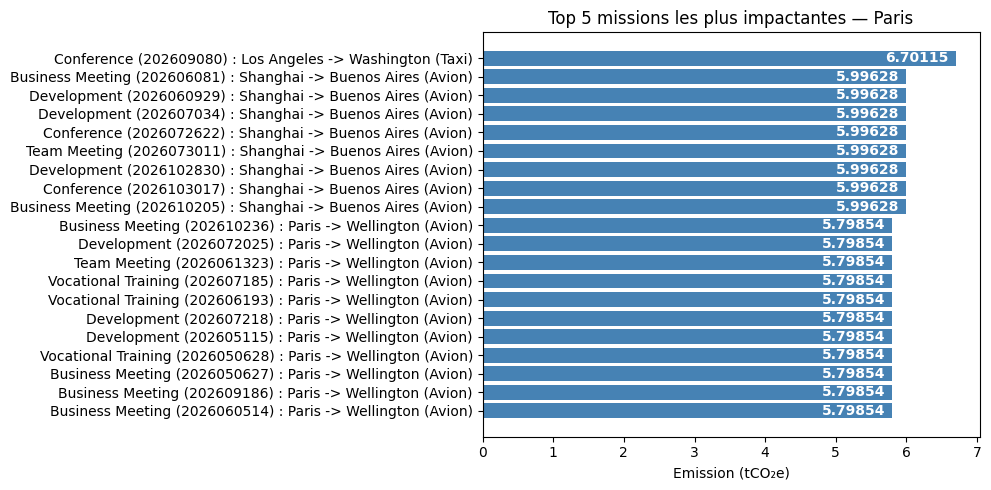

,VILLE_DEPART,VILLE_DESTINATION,TRANSPORT,TYPE_MISSION,ID_DATE_MISSION,EMISSION
2853,Los Angeles,Washington,Taxi,Conference,2026-09-08,6.701153
911,Shanghai,Buenos Aires,Avion,Business Meeting,2026-06-08,5.996280
792,Shanghai,Buenos Aires,Avion,Development,2026-06-09,5.996280
1370,Shanghai,Buenos Aires,Avion,Development,2026-07-03,5.996280
1946,Shanghai,Buenos Aires,Avion,Conference,2026-07-26,5.996280
1919,Shanghai,Buenos Aires,Avion,Team Meeting,2026-07-30,5.996280
4231,Shanghai,Buenos Aires,Avion,Development,2026-10-28,5.996280
3919,Shanghai,Buenos Aires,Avion,Conference,2026-10-30,5.996280
3522,Shanghai,Buenos Aires,Avion,Business Meeting,2026-10-20,5.996280
3740,Paris,Wellington,Avion,Business Meeting,2026-10-23,5.798540


In [291]:
missions_paris = (
    dim_mission
    .join(fait_mission, "ID_MISSION")
    .filter(col("ID_SITE") == "PARIS")
    .select("ID_MISSION", "VILLE_DEPART", "PAYS_DEPART", "VILLE_DESTINATION", "PAYS_DESTINATION", "ALLER_RETOUR", "TRANSPORT", "ID_DATE_MISSION", "TYPE_MISSION")
)

missions_paris_df = missions_paris.toPandas()

missions_paris_df['DISTANCE_KM'] = missions_paris_df.apply(
    lambda row: get_distance_between_cities(
        row['VILLE_DEPART'], row['PAYS_DEPART'],
        row['VILLE_DESTINATION'], row['PAYS_DESTINATION']
    ), axis=1
)

missions_paris_df['EMISSION'] = missions_paris_df.apply(
    lambda row: get_emission(
        row['DISTANCE_KM'], row['TRANSPORT'],
        row['ALLER_RETOUR'], row['PAYS_DEPART'], row['PAYS_DESTINATION']
    ), axis=1
)

top5 = missions_paris_df.sort_values("EMISSION", ascending=False).head(20).copy()
top5["ID_MISSION"] = top5["ID_MISSION"].str.replace("Paris_", "")

top5['LABEL'] = top5["TYPE_MISSION"] + " (" + top5["ID_MISSION"] + ") : " + top5['VILLE_DEPART'] + " -> " + top5['VILLE_DESTINATION'] + " (" + top5['TRANSPORT'] + ")"

# Figure
emission_max = top5['EMISSION'].max()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top5['LABEL'][::-1], top5['EMISSION'][::-1], color='steelblue')

for bar, val in zip(bars, top5['EMISSION'][::-1]):
    ax.text(bar.get_width() - 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.5f}", va='center', ha='right', color='white', fontweight='bold')

ax.barh(top5['LABEL'][::-1], top5['EMISSION'][::-1], color='steelblue')
ax.set_xlabel("Emission (tCO₂e)")
ax.set_title("Top 5 missions les plus impactantes — Paris")
plt.tight_layout()
plt.savefig("top5_missions_paris.png", dpi=150, bbox_inches='tight')
plt.show()

top5[['VILLE_DEPART', 'VILLE_DESTINATION', 'TRANSPORT', 'TYPE_MISSION', 'ID_DATE_MISSION', 'EMISSION']]

Question 19 : Proposer une figure comparant l’impact carbone mensuel des missions en fonction du type de transport et sur chaque site.

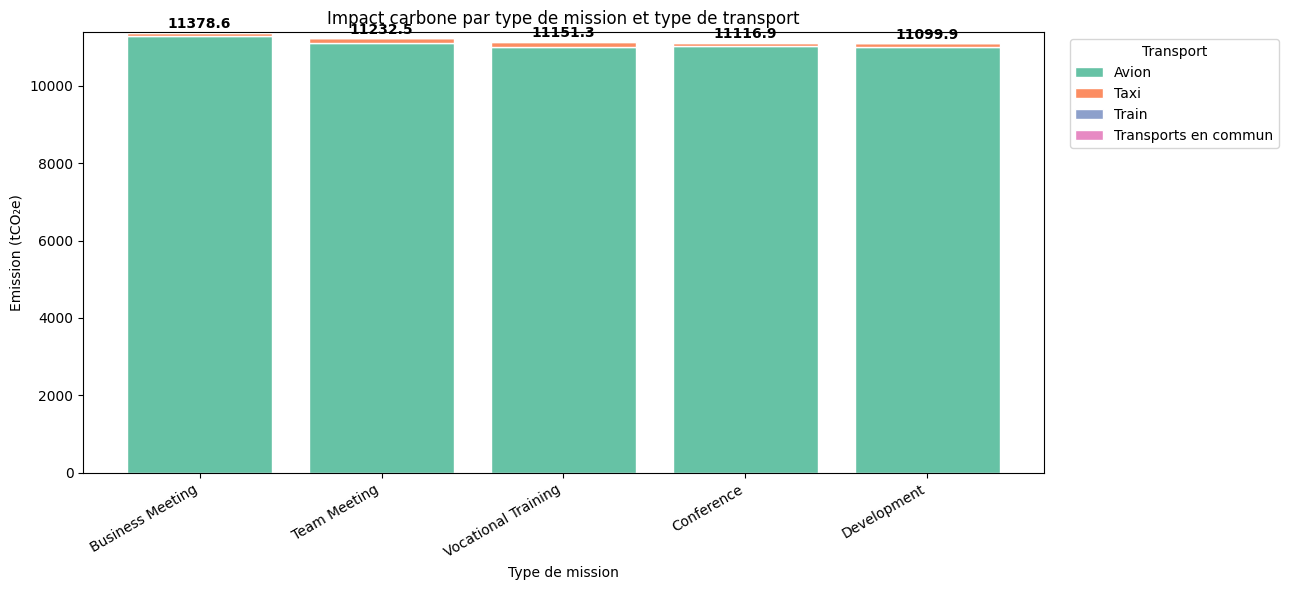

In [293]:
missions_transport = (
    dim_mission
    .join(fait_mission, "ID_MISSION")
    .select("ID_MISSION", "VILLE_DEPART", "PAYS_DEPART", "VILLE_DESTINATION", "PAYS_DESTINATION", "ALLER_RETOUR", "TRANSPORT", "ID_DATE_MISSION", "TYPE_MISSION")
)

missions_transport = missions_transport.toPandas()

missions_transport['DISTANCE_KM'] = missions_transport.apply(
    lambda row: get_distance_between_cities(
        row['VILLE_DEPART'], row['PAYS_DEPART'],
        row['VILLE_DESTINATION'], row['PAYS_DESTINATION']
    ), axis=1
)

missions_transport['EMISSION'] = missions_transport.apply(
    lambda row: get_emission(
        row['DISTANCE_KM'], row['TRANSPORT'],
        row['ALLER_RETOUR'], row['PAYS_DEPART'], row['PAYS_DESTINATION']
    ), axis=1
)

agg = missions_transport.groupby(['TYPE_MISSION', 'TRANSPORT'])['EMISSION'].sum().reset_index()

# Pivot : lignes = TYPE_MISSION, colonnes = TRANSPORT
pivot = agg.pivot(index='TYPE_MISSION', columns='TRANSPORT', values='EMISSION').fillna(0)

# Total par type de mission
pivot['TOTAL'] = pivot.sum(axis=1)
pivot = pivot.sort_values('TOTAL', ascending=False)

# Figure
fig, ax = plt.subplots(figsize=(13, 6))

# Barres par transport (empilées)
transports = [c for c in pivot.columns if c != 'TOTAL']
bottom = pd.Series(0.0, index=pivot.index)
colors = plt.cm.Set2.colors[:len(transports)]

for transport, color in zip(transports, colors):
    ax.bar(pivot.index, pivot[transport], bottom=bottom, label=transport, color=color, edgecolor='white')
    bottom += pivot[transport]

# Annotation du total au-dessus de chaque barre
for i, (idx, total) in enumerate(pivot['TOTAL'].items()):
    ax.text(i, total + pivot['TOTAL'].max() * 0.01, f"{total:.1f}",
            ha='center', fontweight='bold', fontsize=10)

ax.set_xlabel("Type de mission")
ax.set_ylabel("Emission (tCO₂e)")
ax.set_title("Impact carbone par type de mission et type de transport")
ax.legend(title="Transport", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("impact_type_mission_transport.png", dpi=150, bbox_inches='tight')
plt.show()

Question 20 : Proposer une figure illustrant l’impact carbone global mensuel de l’organisation.

In [ ]:
missions = (
    dim_mission
    .join(fait_mission, "ID_MISSION")
    .select("ID_SITE","VILLE_DEPART","PAYS_DEPART", "VILLE_DESTINATION","PAYS_DESTINATION","ALLER_RETOUR","TRANSPORT","ID_DATE_MISSION",month("ID_DATE_MISSION"))
    .withColumnRenamed("month(ID_DATE_MISSION)", "MOIS")
)

missions_df = missions.toPandas()

#Calcul des émissions pour chaque mission
missions_df['DISTANCE_KM'] = missions_df.apply(
    lambda row: get_distance_between_cities(
        row['VILLE_DEPART'],
        row['PAYS_DEPART'],
        row['VILLE_DESTINATION'],
        row['PAYS_DESTINATION'],
    ),
    axis=1
)

missions_df['EMISSION'] = missions_df.apply(
    lambda row: get_emission(
        row['DISTANCE_KM'],
        row['TRANSPORT'],
        row['ALLER_RETOUR'],
        row['PAYS_DEPART'],
        row['PAYS_DESTINATION']
    ),
    axis=1
)

emissions_par_site = missions_df.groupby('MOIS')['EMISSION'].sum().reset_index()
emissions_par_site.columns = ['MOIS', 'Emission_tCO2e']
emissions_par_site

,MOIS,Emission_tCO2e
0,5,9035.558183
1,8,8888.806476
2,10,8880.833804
3,7,8557.763549
4,6,8202.474621
5,9,7964.320902
6,11,3950.217331
7,4,499.292160


In [ ]:
mat_inf = (
    dim_materiel
    .join(fait_materiel, "ID_MATERIEL")
    .select("ID_SITE", "ID_MATERIEL", "TYPE", "MODELE", month("ID_DATE_ACHAT"))
    .withColumnRenamed("month(ID_DATE_ACHAT)", "MOIS")
)

impact_mat = (
    mat_inf
    .join(impact_mat_info_sdf, ["TYPE", "MODELE"])
    .groupBy(col("MOIS"))
    .agg(sum(col("IMPACT")))
)

impact_mat_df = impact_mat.toPandas()
impact_mat_df["sum(IMPACT)"] = impact_mat_df["sum(IMPACT)"] / 1000
impact_mat_df

+----+-----------+
|MOIS|sum(IMPACT)|
+----+-----------+
|   6|     330453|
|   5|     354925|
|   9|     327562|
|   4|      18694|
|   8|     343719|
|   7|     365709|
|  10|     339082|
|  11|     156841|
+----+-----------+



,MOIS,sum(IMPACT)
0,6,330.453
1,5,354.925
2,9,327.562
3,4,18.694
4,8,343.719
5,7,365.709
6,10,339.082
7,11,156.841


In [305]:
#Homogénéisation du type de données
emissions_par_site["MOIS"] = emissions_par_site["MOIS"].astype(int)
impact_mat_df["MOIS"] = impact_mat_df["MOIS"].astype(int)

#Jointure et calcul du total (missions + matériel)
jointure_mois = emissions_par_site.merge(impact_mat_df, on="MOIS")
jointure_mois["TOT_IMPACT"] = jointure["Emission_tCO2e"] + jointure["sum(IMPACT)"]
jointure_mois.sort_values("TOT_IMPACT", ascending=False)

,MOIS,Emission_tCO2e,sum(IMPACT),TOT_IMPACT
0,5,9035.558183,354.925,9390.483183
1,8,8888.806476,343.719,9232.525476
2,10,8880.833804,339.082,9219.915804
3,7,8557.763549,365.709,8923.472549
4,6,8202.474621,330.453,8532.927621
5,9,7964.320902,327.562,8291.882902
6,11,3950.217331,156.841,4107.058331
7,4,499.292160,18.694,517.986160


   MOIS  Emission_tCO2e  sum(IMPACT)   TOT_IMPACT
0     4      499.292160       18.694   517.986160
1     5     9035.558183      354.925  9390.483183
2     6     8202.474621      330.453  8532.927621
3     7     8557.763549      365.709  8923.472549
4     8     8888.806476      343.719  9232.525476
5     9     7964.320902      327.562  8291.882902
6    10     8880.833804      339.082  9219.915804
7    11     3950.217331      156.841  4107.058331


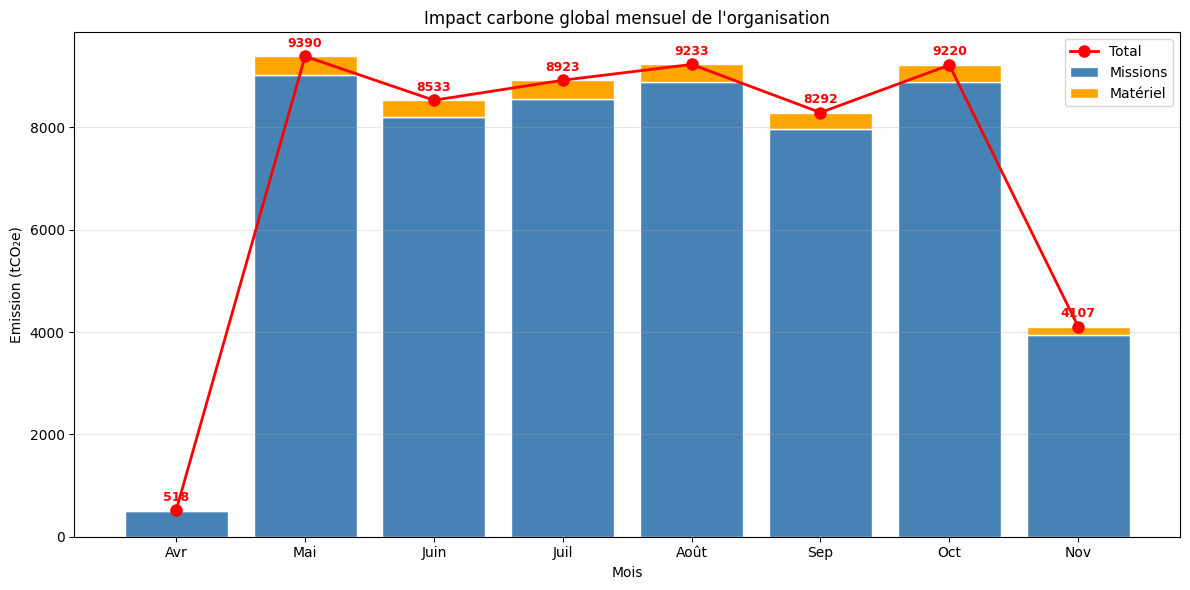

In [307]:
# Tri par mois croissant
df_plot = jointure_mois.sort_values("MOIS").reset_index(drop=True)
print(df_plot)

# Conversion en noms de mois
mois_noms = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']
df_plot['MOIS_LABEL'] = df_plot['MOIS'].apply(lambda m: mois_noms[m-1])

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(df_plot))

# Barres empilées : missions + matériel
ax.bar(x, df_plot['Emission_tCO2e'], label='Missions', color='steelblue', edgecolor='white')
ax.bar(x, df_plot['sum(IMPACT)'], bottom=df_plot['Emission_tCO2e'], label='Matériel', color='orange', edgecolor='white')

# Courbe du total
ax.plot(x, df_plot['TOT_IMPACT'], marker='o', color='red', linewidth=2, markersize=8, label='Total', zorder=5)

# Annotations
for i, val in enumerate(df_plot['TOT_IMPACT']):
    ax.text(i, val + df_plot['TOT_IMPACT'].max() * 0.02, f"{val:.0f}",
            ha='center', fontweight='bold', color='red', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(df_plot['MOIS_LABEL'])
ax.set_xlabel("Mois")
ax.set_ylabel("Emission (tCO₂e)")
ax.set_title("Impact carbone global mensuel de l'organisation")
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("impact_global_mensuel.png", dpi=150, bbox_inches='tight')
plt.show()